# Three-Domain Short-Text Sentiment Corpus — `data.py` demo

This notebook demonstrates `data.py`, the script that reshapes the already
built, normalized, deduplicated, class-balanced sentiment splits (written by
`build_dataset.py` into `output/full_*.json`) into the final
`exp_sel_data_out` schema used by the rest of the pipeline.

Each domain (`rotten_tomatoes`, `sst2`, `tweet_eval`) contributes disjoint
`val` / `test` / `unlabeled_pool` splits plus **nested** train pools at sizes
`{50, 100, 200, 500, 1000, 1500, 2000}` (every smaller pool is a strict subset
of every larger one, fixed seed 42). `data.py` collapses those nested train
pools into one set of unique training rows per domain, tagging each with
`metadata_train_min_n` — the smallest pool size the row belongs to — so any
of the 7 nested sizes can be reconstructed later by filtering on that one
field instead of repeating rows 7 times.

For this demo we use a small subset of just the `rotten_tomatoes` domain
(8 val / 8 test / 8 unlabeled rows, plus tiny nested train pools of size
`{10, 20, 40}` instead of the full `{50...2000}`) so the whole pipeline runs
in seconds. The transformation code below is copied unchanged from `data.py`
— only the config (train sizes, domain list) and the data-loading source are
adapted for the demo.


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru -- not pre-installed on Colab, always install
_pip('loguru==0.7.3')

# matplotlib -- pre-installed on Colab, install locally to match Colab's env
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (copied from data.py, plus matplotlib for the results cell) ---
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

from loguru import logger
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")


1

## Load the demo data

`mini_demo_data.json` holds a small `rotten_tomatoes`-only slice of the raw
split rows that `data.py` normally reads from `output/full_{split}.json`:
`val`, `test`, `unlabeled_pool` (8 rows each) and nested `train` pools at
sizes `{10, 20, 40}` (a shrunk stand-in for the real `{50...2000}`). Each row
has the same shape the real pipeline produces: `{text, label, domain,
lineage_group, split}`.


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-d8fc3d-vocabulary-saturation-predicts-the/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

import os
data = load_data()
print({k: (len(v) if isinstance(v, list) else v) for k, v in data.items()})


{'train_sizes': 3, 'val': 8, 'test': 8, 'unlabeled_pool': 8, 'train': {'10': [{'text': 'a triumph , relentless and beautiful in its downbeat darkness .', 'label': 1, 'domain': 'rotten_tomatoes', 'lineage_group': 'pang_lee_lineage', 'split': 'train_n50'}, {'text': "it's hard to imagine any recent film , independent or otherwise , that makes as much of a mess as this one .", 'label': 0, 'domain': 'rotten_tomatoes', 'lineage_group': 'pang_lee_lineage', 'split': 'train_n50'}, {'text': 'stripped almost entirely of such tools as nudity , profanity and violence , labute does manage to make a few points about modern man and his problematic quest for human connection .', 'label': 1, 'domain': 'rotten_tomatoes', 'lineage_group': 'pang_lee_lineage', 'split': 'train_n50'}, {'text': "it's hard to fairly judge a film like ringu when you've seen the remake first . many of the effective horror elements are dampened through familiarity , [yet] are worthwhile .", 'label': 1, 'domain': 'rotten_tomatoes',

## Config

The original `data.py` hardcodes `TRAIN_SIZES = [50, 100, 200, 500, 1000, 1500, 2000]`
and `DOMAINS = ["rotten_tomatoes", "sst2", "tweet_eval"]`. The demo data only
covers one domain and tiny nested train pools, so those two constants are
shrunk to match — everything else in the transformation logic is untouched.


In [4]:
# --- Config (shrunk from data.py's originals, shown in comments) ---
TRAIN_SIZES = data["train_sizes"]          # demo: [10, 20, 40]   (original: [50, 100, 200, 500, 1000, 1500, 2000])
DOMAINS = ["rotten_tomatoes"]               # demo: 1 domain      (original: ["rotten_tomatoes", "sst2", "tweet_eval"])


## `load_split` — read one split's rows

In the original script this reads `output/full_{name}.json` from disk. Here
it reads the same-shaped rows out of the `data` dict we already loaded
(`val`, `test`, `unlabeled_pool` are lists; `train` is keyed by pool size).


In [5]:
def load_split(name: str) -> list[dict[str, Any]]:
    # original: path = OUTPUT_DIR / f"full_{name}.json"; rows = json.loads(path.read_text())
    logger.info(f"Loading split '{name}' from demo data")
    if name.startswith("train_n"):
        n = name.removeprefix("train_n")
        rows = data["train"][n]
    else:
        rows = data[name]
    assert isinstance(rows, list), f"{name} did not contain a list"
    return rows


## `build_examples_for_domain` — collapse nested train pools + reshape to schema

This is copied unchanged from `data.py`. It emits `val` / `test` /
`unlabeled_pool` rows as-is (they're disjoint by construction), then dedupes
the nested train pools by exact text, keeping the smallest pool size (`min_n`)
each row first appears at, so that `metadata_train_min_n <= N` reconstructs
the train pool for any `N` in `TRAIN_SIZES`.


In [6]:
def build_examples_for_domain(domain: str, val: list, test: list, unlabeled: list, train_by_n: dict[int, list]) -> list[dict[str, Any]]:
    """Collapse nested train pools into unique rows + metadata_train_min_n,
    then combine with val/test/unlabeled_pool (already disjoint) into one
    flat example list for this domain."""
    examples: list[dict[str, Any]] = []

    # --- val / test / unlabeled_pool: emitted as-is, disjoint by construction ---
    for split_name, rows in [("val", val), ("test", test), ("unlabeled_pool", unlabeled)]:
        for r in rows:
            examples.append(
                {
                    "input": r["text"],
                    "output": str(r["label"]),
                    "metadata_split": split_name,
                    "metadata_lineage_group": r["lineage_group"],
                    "metadata_task_type": "classification",
                    "metadata_n_classes": 2,
                }
            )

    # --- train pools: nested, so dedupe by exact text and keep the MIN n it appears at ---
    min_n_by_text: dict[str, int] = {}
    row_by_text: dict[str, dict[str, Any]] = {}
    for n in TRAIN_SIZES:
        for r in train_by_n.get(n, []):
            key = r["text"]
            row_by_text[key] = r
            if key not in min_n_by_text or n < min_n_by_text[key]:
                min_n_by_text[key] = n

    n_raw = sum(len(train_by_n.get(n, [])) for n in TRAIN_SIZES)
    logger.info(
        f"{domain}: collapsed {n_raw} nested train-pool row-occurrences into "
        f"{len(min_n_by_text)} unique train examples (min_n metadata preserves nesting)"
    )

    for key, min_n in min_n_by_text.items():
        r = row_by_text[key]
        examples.append(
            {
                "input": r["text"],
                "output": str(r["label"]),
                "metadata_split": "train",
                "metadata_train_min_n": min_n,
                "metadata_lineage_group": r["lineage_group"],
                "metadata_task_type": "classification",
                "metadata_n_classes": 2,
            }
        )

    return examples


## Driver — adapted from `data.py`'s `main()`

Same structure as the original `main()`: load every split, filter each to
its domain, run `build_examples_for_domain`, and assemble the final
`exp_sel_data_out`-shaped dict. The only changes are (1) `DOMAINS`/`TRAIN_SIZES`
now come from the shrunk config cell, and (2) the result is kept in memory
(`out`) instead of being written to `full_data_out.json`.


In [7]:
val_all = load_split("val")
test_all = load_split("test")
unlabeled_all = load_split("unlabeled_pool")
train_all_by_n = {n: load_split(f"train_n{n}") for n in TRAIN_SIZES}

datasets_out = []
for domain in DOMAINS:
    val = [r for r in val_all if r["domain"] == domain]
    test = [r for r in test_all if r["domain"] == domain]
    unlabeled = [r for r in unlabeled_all if r["domain"] == domain]
    train_by_n = {n: [r for r in train_all_by_n[n] if r["domain"] == domain] for n in TRAIN_SIZES}

    examples = build_examples_for_domain(domain, val, test, unlabeled, train_by_n)
    assert len(examples) > 0, f"{domain}: produced zero examples"
    datasets_out.append({"dataset": domain, "examples": examples})
    logger.info(f"{domain}: {len(examples)} total examples "
                f"(val={len(val)}, test={len(test)}, unlabeled_pool={len(unlabeled)}, "
                f"train_unique={len(examples) - len(val) - len(test) - len(unlabeled)})")

out = {
    "metadata": {
        "description": "Three-domain short-text binary-sentiment corpus (rotten_tomatoes, sst2, tweet_eval) -- demo subset",
        "lineage_caveat": (
            "rotten_tomatoes and sst2 share upstream Pang & Lee lineage (metadata_lineage_group="
            "'pang_lee_lineage') and are NOT independent evidence of anything; tweet_eval "
            "(metadata_lineage_group='independent') is the only genuinely independent domain."
        ),
        "train_sizes": TRAIN_SIZES,
        "train_nesting_note": (
            "Train examples are deduplicated across the nested pool sizes; use "
            "metadata_train_min_n <= N to reconstruct the train_nN pool for any N in train_sizes."
        ),
    },
    "datasets": datasets_out,
}

total = sum(len(d["examples"]) for d in datasets_out)
logger.info(f"Built {len(datasets_out)} dataset(s), {total} total examples (demo, kept in-memory as `out`)")


21:50:08|INFO   |Loading split 'val' from demo data


21:50:08|INFO   |Loading split 'test' from demo data


21:50:08|INFO   |Loading split 'unlabeled_pool' from demo data


21:50:08|INFO   |Loading split 'train_n10' from demo data


21:50:08|INFO   |Loading split 'train_n20' from demo data


21:50:08|INFO   |Loading split 'train_n40' from demo data


21:50:08|INFO   |rotten_tomatoes: collapsed 70 nested train-pool row-occurrences into 40 unique train examples (min_n metadata preserves nesting)


21:50:08|INFO   |rotten_tomatoes: 64 total examples (val=8, test=8, unlabeled_pool=8, train_unique=40)


21:50:08|INFO   |Built 1 dataset(s), 64 total examples (demo, kept in-memory as `out`)


## Results

Inspect the reshaped output: split counts per domain, the nested train pools
correctly collapsed into unique rows tagged with `metadata_train_min_n`, and
class balance.


domain            split               n  n_pos  n_neg
-----------------------------------------------------
rotten_tomatoes   val                 8      4      4
rotten_tomatoes   test                8      1      7
rotten_tomatoes   unlabeled_pool      8      5      3
rotten_tomatoes   train              40     16     24

Unique train rows: 40  |  new rows introduced at each pool size: {10: 10, 20: 10, 40: 20}
  reconstructed train_n10 pool size: 10 (expected 10)
  reconstructed train_n20 pool size: 20 (expected 20)
  reconstructed train_n40 pool size: 40 (expected 40)


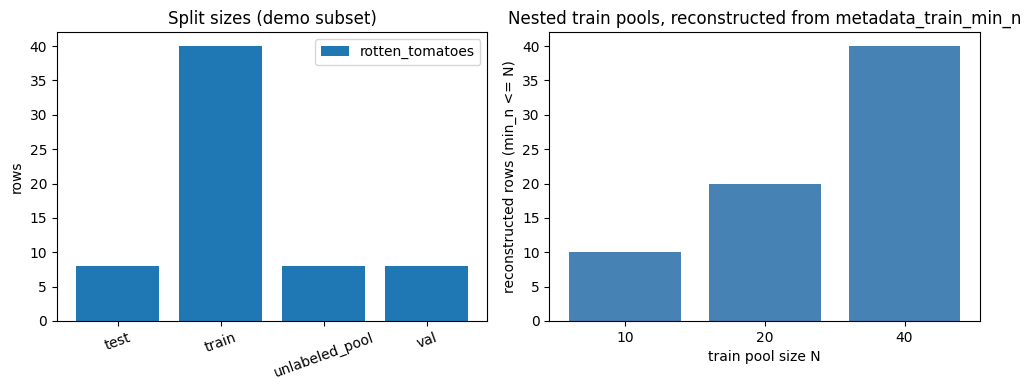

In [8]:
print(f"{'domain':<18}{'split':<16}{'n':>5}{'n_pos':>7}{'n_neg':>7}")
print("-" * 53)
split_counts = {}
for d in datasets_out:
    domain = d["dataset"]
    by_split = {}
    for ex in d["examples"]:
        by_split.setdefault(ex["metadata_split"], []).append(ex)
    for split_name, rows in by_split.items():
        n_pos = sum(1 for r in rows if r["output"] == "1")
        n_neg = sum(1 for r in rows if r["output"] == "0")
        print(f"{domain:<18}{split_name:<16}{len(rows):>5}{n_pos:>7}{n_neg:>7}")
        split_counts[(domain, split_name)] = len(rows)

# Show the nested-train-pool collapse explicitly: metadata_train_min_n distribution
train_min_ns = [ex["metadata_train_min_n"] for d in datasets_out for ex in d["examples"] if ex["metadata_split"] == "train"]
n_by_min_n = {n: train_min_ns.count(n) for n in sorted(set(train_min_ns))}
print(f"\nUnique train rows: {len(train_min_ns)}  |  new rows introduced at each pool size: {n_by_min_n}")
for N in TRAIN_SIZES:
    reconstructed = sum(1 for m in train_min_ns if m <= N)
    print(f"  reconstructed train_n{N} pool size: {reconstructed} (expected {N})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

splits = sorted({s for (_, s) in split_counts})
domains_present = sorted({d for (d, _) in split_counts})
x = range(len(splits))
for domain in domains_present:
    heights = [split_counts.get((domain, s), 0) for s in splits]
    axes[0].bar(x, heights, label=domain)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(splits, rotation=20)
axes[0].set_ylabel("rows")
axes[0].set_title("Split sizes (demo subset)")
axes[0].legend()

axes[1].bar([str(n) for n in TRAIN_SIZES], [sum(1 for m in train_min_ns if m <= N) for N in TRAIN_SIZES], color="steelblue")
axes[1].set_xlabel("train pool size N")
axes[1].set_ylabel("reconstructed rows (min_n <= N)")
axes[1].set_title("Nested train pools, reconstructed from metadata_train_min_n")

plt.tight_layout()
plt.show()
